### TCN

既然卷积可以在图片上滑动抓取特征，为什么不能在时间轴上滑动抓取历史规律

#### 1. 两大核心科技
- 因果卷积：卷积核会看中心像素周围的所有点，但是时间序列中，如果t时刻预测到了t+1时刻的数据，那就是穿越了。因此，TCN的卷积核在滑动时，确保t时刻的输出只取决于t时刻及其之前的输入，保证了逻辑上的因果
- 膨胀卷积：层数越深，神经元看到的图像范围越广。如果让TCN记住很长一段历史，传统的卷积需要堆叠非常多的层。TCN采用跳着看的策略，第一层卷积核看相邻的点，第二层可能隔一个点看一次，第三层隔三个点。这种膨胀系数随深度指数级增长的策略，可以让模型用很少的层数获得巨大的历史视野

#### 2.TCN与RNN的博弈
- 并行性:不像RNN必须排队计算，TCN的每层卷积都可以在整个序列上运行，训练速度极快
- 梯度稳定：RNN容易遇到梯度消失，TCN借鉴了残差链接的思路，让梯度更加稳定
- 灵活内存占用：RNN需要保存每个步长的隐藏状态，TCN只需要保存卷积核

#### 3. 应用场景
- 超长期时间序列预测
- 实时信号处理
- 音频处理
- 动作识别
- 并行训练优势场景

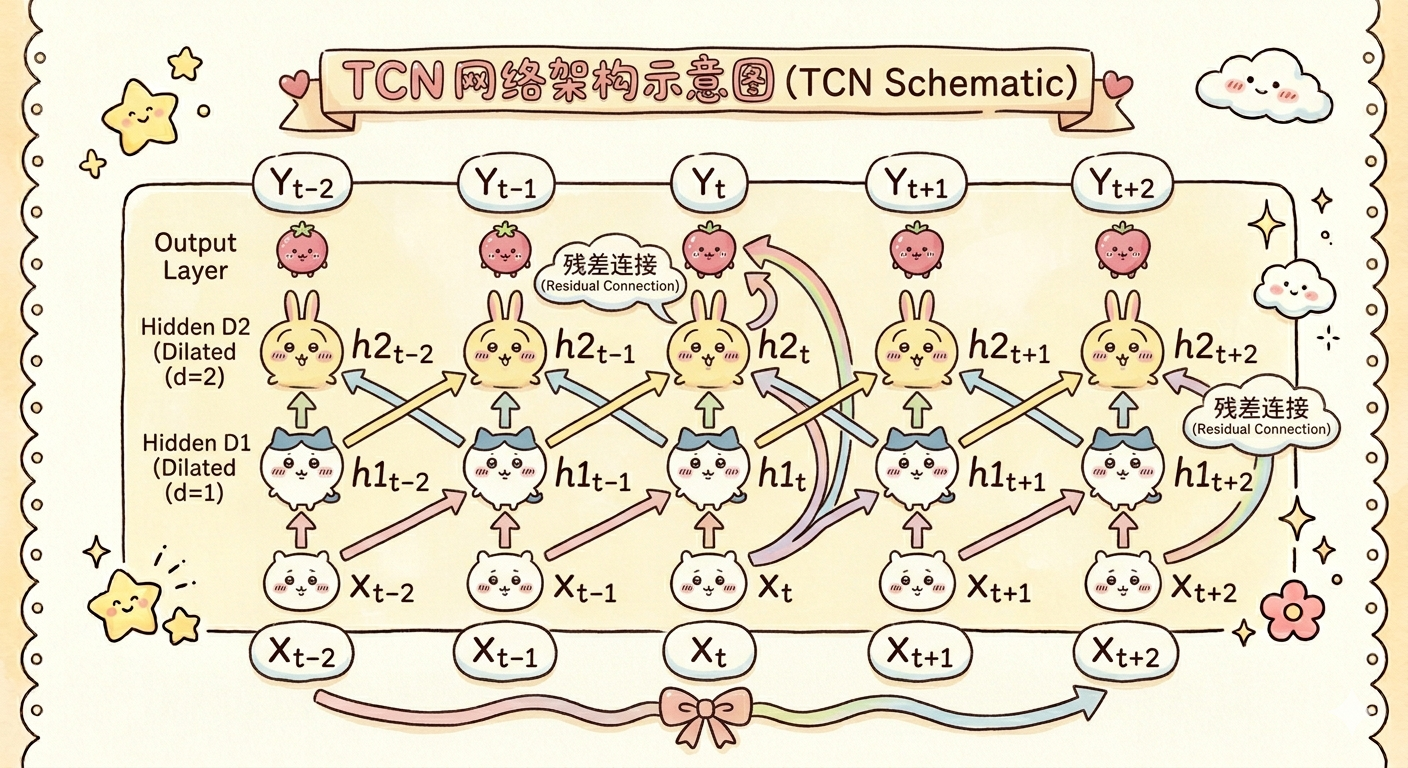

### 案例：股价预测
- 数据：利用Tushare获取的股票数据，包括贵州茅台2010-2025年的日线数据

In [1]:
import tushare as ts
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [2]:
token = '112807077fb46e02a0f4f4dbf69c700b897c3bbf6d641138609b20e9'
ts.set_token(token)
pro = ts.pro_api()

df_daily = pro.daily(ts_code='600519.SH',
                     start_date='20100101',
                     end_date='20251231')
df_daily = df_daily.sort_values('trade_date').reset_index(drop=True)

# 添加暴跌标记
df_daily['Crash'] = (df_daily['close'].pct_change() < -0.05).astype(int)

# 计算技术指标
def add_technical_features(df):
    df['MA7'] = df['close'].rolling(7).mean()
    df['MA21'] = df['close'].rolling(21).mean()
    exp12 = df['close'].ewm(span=12, adjust=False).mean()
    exp26 = df['close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp12 - exp26
    df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['Volatility'] = df['close'].rolling(20).std()
    return df

df = add_technical_features(df_daily).dropna().reset_index(drop=True)

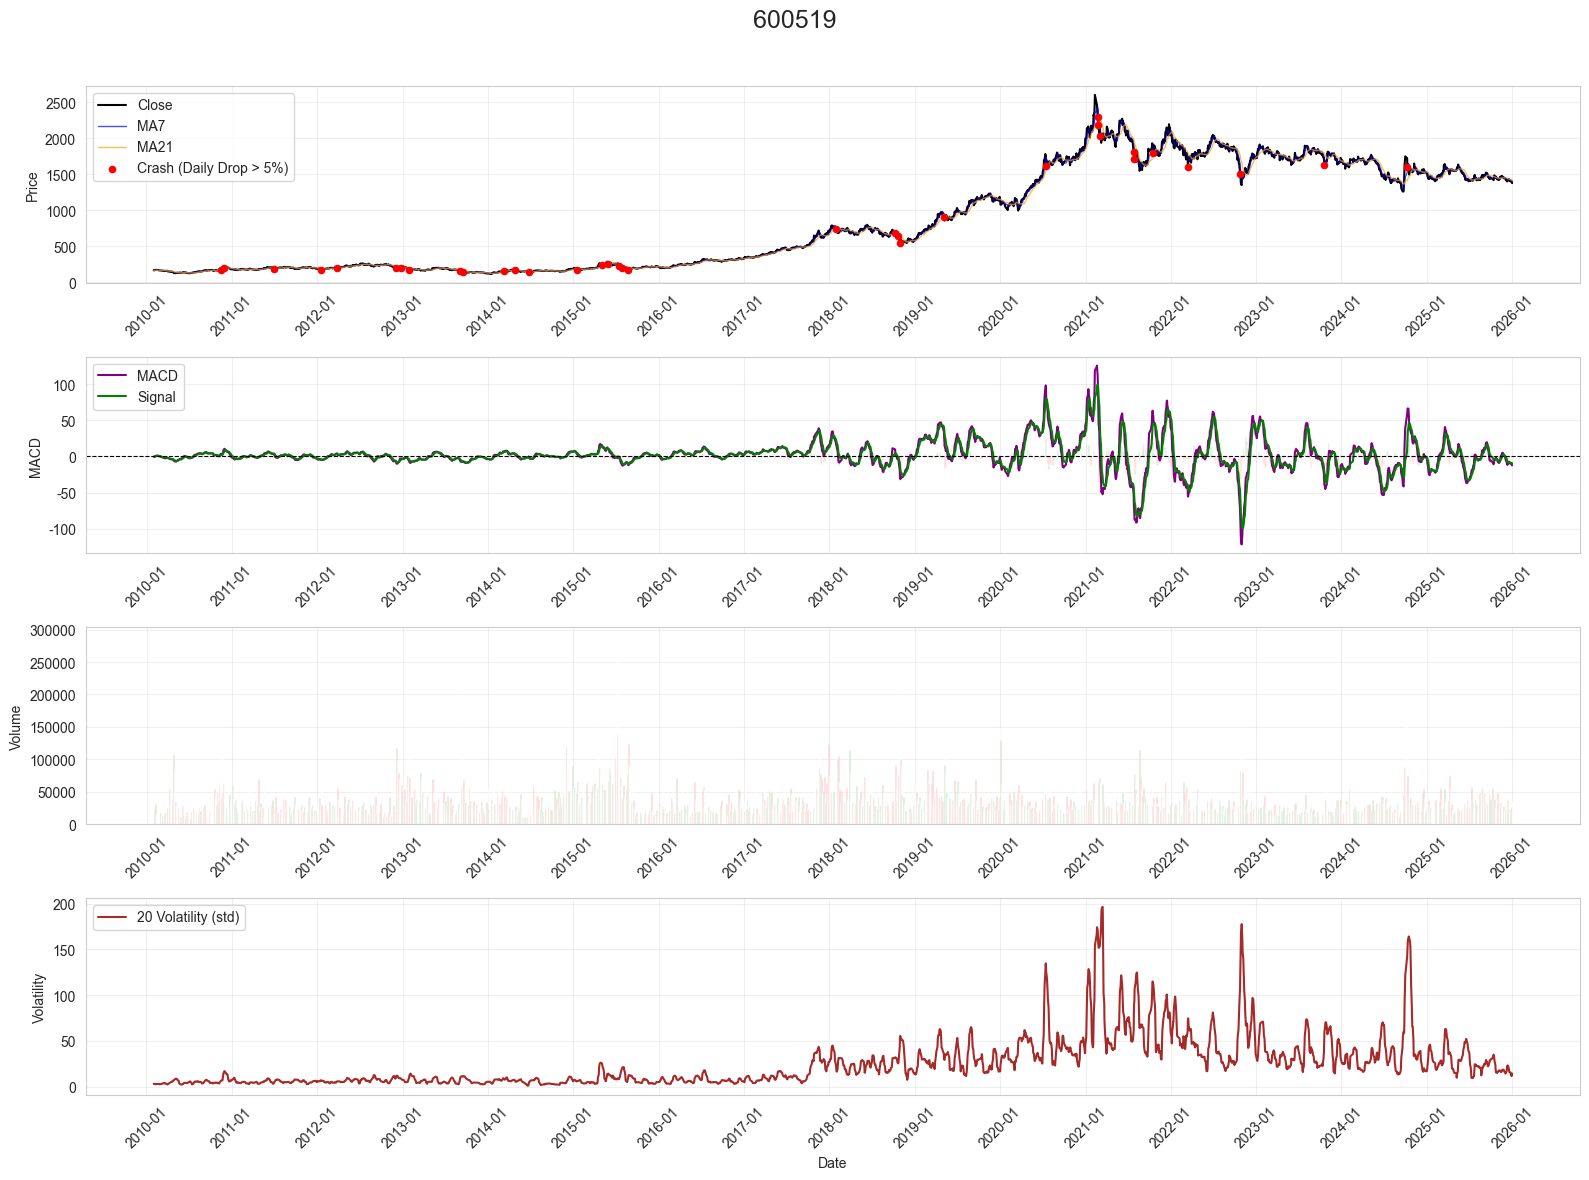

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 设置中文显示和样式
plt.rcParams['font.family'] = 'SimSun'
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
sns.set_style('whitegrid')

df['trade_date'] = pd.to_datetime(df['trade_date'])

# 创建画布和子图
fig = plt.figure(figsize=(16, 12))
fig.suptitle('600519', fontsize=18, y=0.98)

ax1 = plt.subplot(4, 1, 1)
ax1.plot(df['trade_date'], df['close'], label='Close', color='black', linewidth=1.5)
ax1.plot(df['trade_date'], df['MA7'], label='MA7', color='blue', alpha=0.7, linewidth=1)
ax1.plot(df['trade_date'], df['MA21'], label='MA21', color='orange', alpha=0.7, linewidth=1)
# 标记暴跌点
crash_dates = df[df['Crash'] == 1]['trade_date']
crash_prices = df[df['Crash'] == 1]['close']
ax1.scatter(crash_dates, crash_prices, color='red', s=20, label='Crash (Daily Drop > 5%)', zorder=3)
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# MACD 与信号线
ax2 = plt.subplot(4, 1, 2)
ax2.plot(df['trade_date'], df['MACD'], label='MACD', color='purple')
ax2.plot(df['trade_date'], df['Signal'], label='Signal', color='green')
# 绘制柱状线 (MACD - Signal)
ax2.bar(df['trade_date'], df['MACD'] - df['Signal'], 
        color=['red' if val < 0 else 'green' for val in (df['MACD'] - df['Signal'])], 
        alpha=0.3, width=0.8)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_ylabel('MACD')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# 成交量 (柱状图)
ax3 = plt.subplot(4, 1, 3)
# 根据涨跌着色: 涨为红色，跌为绿色 (国内惯例)
colors = ['red' if close >= open_ else 'green' 
          for close, open_ in zip(df['close'], df['open'])]
ax3.bar(df['trade_date'], df['vol'], color=colors, alpha=0.6, width=0.8)
ax3.set_ylabel('Volume')
ax3.grid(True, alpha=0.3)

# 波动率
ax4 = plt.subplot(4, 1, 4)
ax4.plot(df['trade_date'], df['Volatility'], label='20 Volatility (std)', color='brown')
ax4.set_xlabel('Date')
ax4.set_ylabel('Volatility')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3)

# 格式化x轴日期 (避免过于拥挤)
for ax in [ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()

In [4]:
features = ['open', 'high', 'low', 'close', 'vol', 'MA7', 'MA21', 'MACD', 'Signal', 'Volatility']
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(df[features])

# 构造时间窗口（60天预测下一天）
window_size = 60
X, y = [], []
for i in range(window_size, len(scaled_features)):
    X.append(scaled_features[i - window_size:i])   # 过去60天
    y.append(scaled_features[i, 3])                # 第61天的close（归一化后）

X, y = np.array(X), np.array(y)

In [5]:
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:-30]   # 最后30天作为测试集
y_train, y_val = y[:split_idx], y[split_idx:-30]
X_test, y_test = X[-30:], y[-30:]                  # 测试集30个样本

# 转换为Tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32).permute(0, 2, 1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

In [6]:
class Chomp1d(nn.Module):
    """移除卷积输出末尾多余的时间步，保持因果性"""
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    """
    单个残差块：膨胀因果卷积 + ReLU + Dropout
    """
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCN(nn.Module):
    """
    TCN模型：堆叠多个TemporalBlock，最后接一个线性层输出预测值
    """
    def __init__(self, input_size, output_size, num_channels, kernel_size=3, dropout=0.2):
        """
        input_size: 输入特征维度
        output_size: 输出维度（1）
        num_channels: 每层隐藏通道数列表，例如 [64, 64, 128, 128]
        kernel_size: 卷积核大小
        dropout: Dropout比率
        """
        super(TCN, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = input_size if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size,
                                     stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size,
                                     dropout=dropout)]
        self.network = nn.Sequential(*layers)
        # 全局平均池化或取最后一个时间步，这里取最后一个时间步
        self.linear = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        # x: (batch, input_size, seq_len)
        out = self.network(x)  # (batch, num_channels[-1], seq_len)
        # 取最后一个时间步的输出
        out = out[:, :, -1]    # (batch, num_channels[-1])
        out = self.linear(out) # (batch, output_size)
        return out

Epoch 1/100, Train Loss: 0.029544, Val Loss: 0.001396
Epoch 2/100, Train Loss: 0.001819, Val Loss: 0.000836
Epoch 3/100, Train Loss: 0.001089, Val Loss: 0.000677
Epoch 4/100, Train Loss: 0.000986, Val Loss: 0.000387
Epoch 5/100, Train Loss: 0.000738, Val Loss: 0.000373
Epoch 6/100, Train Loss: 0.000583, Val Loss: 0.000559
Epoch 7/100, Train Loss: 0.000467, Val Loss: 0.000230
Epoch 8/100, Train Loss: 0.000393, Val Loss: 0.000449
Epoch 9/100, Train Loss: 0.000293, Val Loss: 0.000211
Epoch 10/100, Train Loss: 0.000243, Val Loss: 0.000307
Epoch 11/100, Train Loss: 0.000209, Val Loss: 0.000189
Epoch 12/100, Train Loss: 0.000157, Val Loss: 0.000274
Epoch 13/100, Train Loss: 0.000151, Val Loss: 0.000160
Epoch 14/100, Train Loss: 0.000128, Val Loss: 0.000155
Epoch 15/100, Train Loss: 0.000118, Val Loss: 0.000150
Epoch 16/100, Train Loss: 0.000110, Val Loss: 0.000199
Epoch 17/100, Train Loss: 0.000107, Val Loss: 0.000195
Epoch 18/100, Train Loss: 0.000120, Val Loss: 0.000319
Epoch 19/100, Train

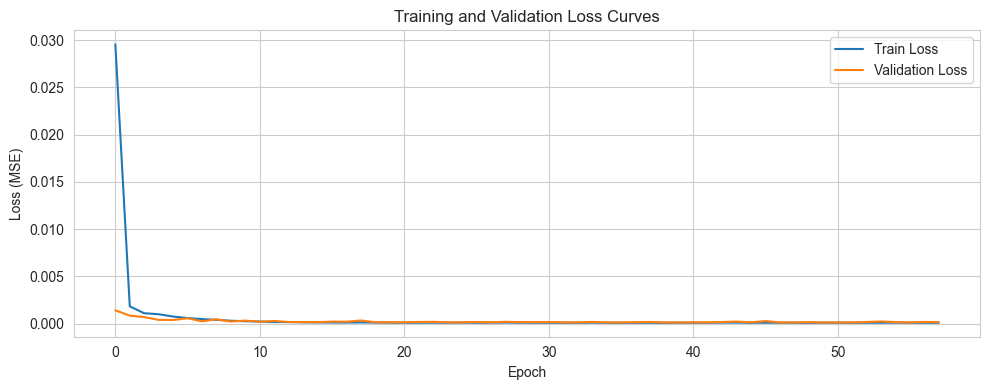

加载最佳模型，验证损失: 0.000113


In [7]:
input_dim = X_train.shape[2]      # 特征数
output_dim = 1
num_channels = [64, 64, 128, 128] # 可调整的TCN结构
model = TCN(input_size=input_dim, output_size=output_dim,
            num_channels=num_channels, kernel_size=3, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 早停参数
patience = 8
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # 验证阶段
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

    # 早停检查
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        torch.save(best_model_state, 'best_tcn_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# 加载最佳模型
model.load_state_dict(best_model_state)
print(f"加载最佳模型，验证损失: {best_val_loss:.6f}")

In [8]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model.eval()
y_pred_norm = []
y_true_norm = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X).cpu().numpy()
        y_pred_norm.extend(outputs.flatten())
        y_true_norm.extend(batch_y.numpy().flatten())

y_pred_norm = np.array(y_pred_norm)
y_true_norm = np.array(y_true_norm)

# 反归一化
close_min = scaler.data_min_[features.index('close')]
close_max = scaler.data_max_[features.index('close')]
def inverse_transform(y_norm):
    return y_norm * (close_max - close_min) + close_min

y_true = inverse_transform(y_true_norm)
y_pred = inverse_transform(y_pred_norm)

# 计算指标
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)


print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE:  19.70
MSE:  491.29
RMSE: 22.17


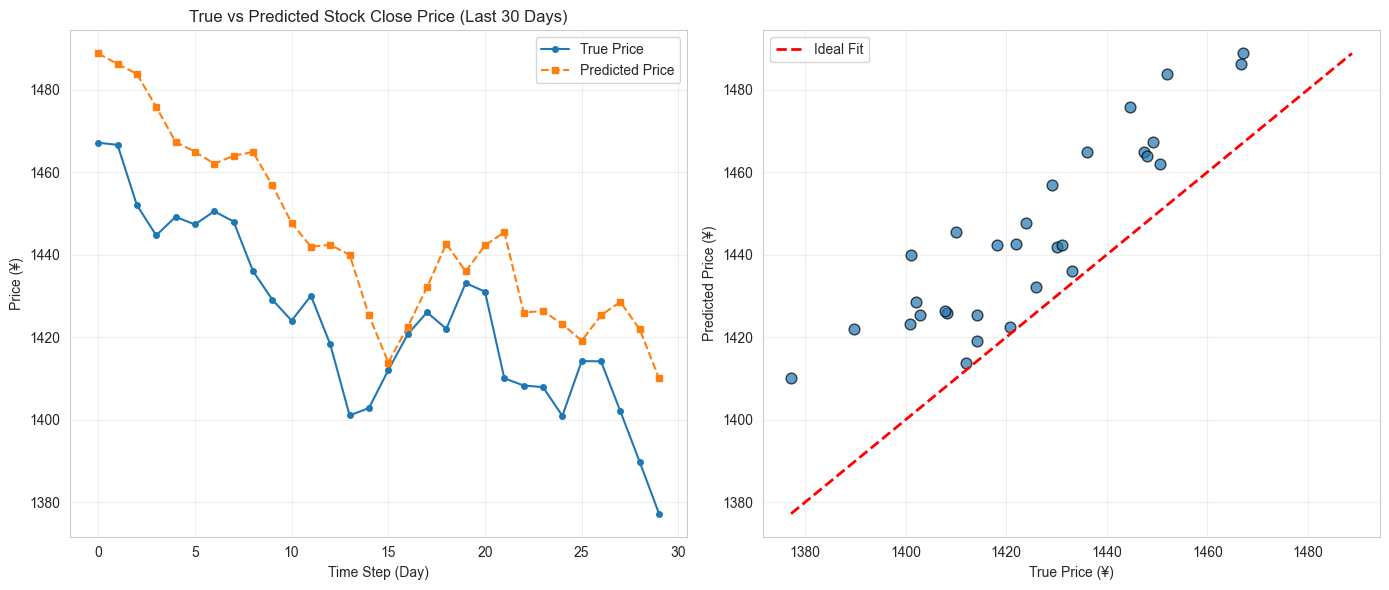

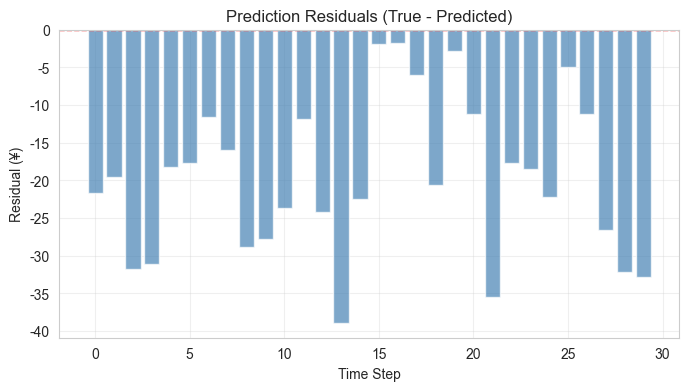

In [9]:
plt.figure(figsize=(14, 6))

# 真实值 vs 预测值（折线图）
plt.subplot(1, 2, 1)
plt.plot(y_true, label='True Price', marker='o', linestyle='-', linewidth=1.5, markersize=4)
plt.plot(y_pred, label='Predicted Price', marker='s', linestyle='--', linewidth=1.5, markersize=4)
plt.title('True vs Predicted Stock Close Price (Last 30 Days)')
plt.xlabel('Time Step (Day)')
plt.ylabel('Price (¥)')
plt.legend()
plt.grid(True, alpha=0.3)

# 散点图 + 理想对角线
plt.subplot(1, 2, 2)
plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k', s=60)
# 绘制 y=x 参考线
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('True Price (¥)')
plt.ylabel('Predicted Price (¥)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 残差图（诊断预测误差分布）
plt.figure(figsize=(8, 4))
residuals = y_true - y_pred
plt.bar(range(len(residuals)), residuals, color='steelblue', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.title('Prediction Residuals (True - Predicted)')
plt.xlabel('Time Step')
plt.ylabel('Residual (¥)')
plt.grid(True, alpha=0.3)
plt.show()